Import package

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

Load Data

In [17]:
df = pd.read_csv('Traffic_Collision_Data.csv', low_memory=False)
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (621677, 18)

Columns:
['DR Number', 'Date Reported', 'Date Occurred', 'Time Occurred', 'Area ID', 'Area Name', 'Reporting District', 'Crime Code', 'Crime Code Description', 'MO Codes', 'Victim Age', 'Victim Sex', 'Victim Descent', 'Premise Code', 'Premise Description', 'Address', 'Cross Street', 'Location']


,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,MO Codes,Victim Age,Victim Sex,Victim Descent,Premise Code,Premise Description,Address,Cross Street,Location
0,212013850,09/03/2021,09/02/2021,2335,20,Olympic,2021,997,TRAFFIC COLLISION,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)"
1,221417787,10/17/2022,10/17/2022,1620,14,Pacific,1406,997,TRAFFIC COLLISION,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)"
2,221418141,10/26/2022,10/26/2022,1135,14,Pacific,1434,997,TRAFFIC COLLISION,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)"
3,222017859,12/01/2022,12/01/2022,230,20,Olympic,2044,997,TRAFFIC COLLISION,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)"
4,190319651,08/24/2019,08/24/2019,450,3,Southwest,356,997,TRAFFIC COLLISION,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)"


In [18]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

DR Number                   int64
Date Reported              object
Date Occurred              object
Time Occurred               int64
Area ID                     int64
Area Name                  object
Reporting District          int64
Crime Code                  int64
Crime Code Description     object
MO Codes                   object
Victim Age                float64
Victim Sex                 object
Victim Descent             object
Premise Code              float64
Premise Description        object
Address                    object
Cross Street               object
Location                   object
dtype: object

Missing values:
DR Number                     0
Date Reported                 0
Date Occurred                 0
Time Occurred                 0
Area ID                       0
Area Name                     0
Reporting District            0
Crime Code                    0
Crime Code Description        0
MO Codes                  87324
Victim Age                88194
Victi

Combine date + time into a single datetime column

In [19]:
df['Time Occurred'] = df['Time Occurred'].astype(str).str.zfill(4)  # e.g. 830 -> 0830
df['datetime'] = pd.to_datetime(
    df['Date Occurred'] + ' ' + df['Time Occurred'],
    format='%m/%d/%Y %H%M',
    errors='coerce'
)

print(f"Datetime nulls after parsing: {df['datetime'].isnull().sum()}")

Datetime nulls after parsing: 0


Extract Lat/Lon from Location

In [20]:
# Location column is in format "(lat, lon)"
df['Location'] = df['Location'].str.strip()
df['Latitude'] = df['Location'].str.extract(r'\(([^,]+),').astype(float)
df['Longitude'] = df['Location'].str.extract(r',\s*([^)]+)\)').astype(float)

print(f"Null Latitude: {df['Latitude'].isnull().sum()}")
print(f"Null Longitude: {df['Longitude'].isnull().sum()}")
print(f"Zero coordinates: {((df['Latitude'] == 0) | (df['Longitude'] == 0)).sum()}")

Null Latitude: 0
Null Longitude: 0
Zero coordinates: 965


Clean & Filter

In [21]:
df_clean = df.copy()

# 1. Drop column you don't need
df_clean = df_clean.drop(columns=['Cross Street'])

# 2. Must drop rows where MO Codes is null (it's your target variable)
df_clean = df_clean[df_clean['MO Codes'].notnull()]

# 3. Fill Victim Age with median instead of dropping
df_clean['Victim Age'] = df_clean['Victim Age'].fillna(df_clean['Victim Age'].median())

# 4. Fill Victim Sex unknown
df_clean['Victim Sex'] = df_clean['Victim Sex'].fillna('X')

# 5. Drop remaining nulls (Premise Code/Description ~960 rows, negligible)
df_clean = df_clean.dropna()

# 6. Drop invalid/zero coordinates
df_clean = df_clean[
    (df_clean['Latitude'] != 0) &
    (df_clean['Longitude'] != 0)
]

# 7. Filter to LA bounding box
df_clean = df_clean[
    (df_clean['Latitude'].between(33.7, 34.35)) &
    (df_clean['Longitude'].between(-118.7, -118.15))
]

# 8. Drop duplicates
df_clean = df_clean.drop_duplicates(subset='DR Number')

print(f"Original rows : {len(df)}")
print(f"Cleaned rows  : {len(df_clean)}")
print(f"Rows dropped  : {len(df) - len(df_clean)}")

Original rows : 621677
Cleaned rows  : 521973
Rows dropped  : 99704


In [22]:
df_clean

,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,MO Codes,Victim Age,Victim Sex,Victim Descent,Premise Code,Premise Description,Address,Location,datetime,Latitude,Longitude
0,212013850,09/03/2021,09/02/2021,2335,20,Olympic,2021,997,TRAFFIC COLLISION,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,"(34.063, -118.3141)",2021-09-02 23:35:00,34.0630,-118.3141
3,222017859,12/01/2022,12/01/2022,0230,20,Olympic,2044,997,TRAFFIC COLLISION,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,"(34.0545, -118.3009)",2022-12-01 02:30:00,34.0545,-118.3009
4,190319651,08/24/2019,08/24/2019,0450,3,Southwest,356,997,TRAFFIC COLLISION,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,"(34.0255, -118.3002)",2019-08-24 04:50:00,34.0255,-118.3002
5,190319680,08/30/2019,08/30/2019,2320,3,Southwest,355,997,TRAFFIC COLLISION,3037 3006 3028 3030 3039 3101 4003,30.0,F,H,101.0,STREET,JEFFERSON BL,"(34.0256, -118.3089)",2019-08-30 23:20:00,34.0256,-118.3089
6,190413769,08/25/2019,08/25/2019,0545,4,Hollenbeck,422,997,TRAFFIC COLLISION,3101 3401 3701 3006 3030,38.0,M,X,101.0,STREET,N BROADWAY,"(34.0738, -118.2078)",2019-08-25 05:45:00,34.0738,-118.2078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621671,251004180,02/22/2025,02/22/2025,1750,10,West Valley,1063,997,TRAFFIC COLLISION,3009 3024 4010 3033 3035 3037 3101,25.0,M,O,101.0,STREET,VENTURA BL,"(34.1688, -118.5356)",2025-02-22 17:50:00,34.1688,-118.5356
621673,251504225,03/06/2025,03/06/2025,0810,15,N Hollywood,1538,997,TRAFFIC COLLISION,3004 3026 3033 3034 3036,25.0,F,W,101.0,STREET,BURBANK BL,"(34.1722, -118.3703)",2025-03-06 08:10:00,34.1722,-118.3703
621674,251604130,02/24/2025,02/24/2025,0910,16,Foothill,1636,997,TRAFFIC COLLISION,3012 3036 3103 3002 3028 4026,35.0,M,W,101.0,STREET,SUNLAND BL,"(34.2602, -118.3395)",2025-02-24 09:10:00,34.2602,-118.3395
621675,251604153,03/07/2025,03/07/2025,1510,16,Foothill,1602,997,TRAFFIC COLLISION,3008 3026 4026 3033 3034 3037 3602,64.0,M,H,101.0,STREET,GLENOAKS BL,"(34.2752, -118.4133)",2025-03-07 15:10:00,34.2752,-118.4133


In [23]:
print("\nMissing values:")
print(df_clean.isnull().sum())


Missing values:
DR Number                 0
Date Reported             0
Date Occurred             0
Time Occurred             0
Area ID                   0
Area Name                 0
Reporting District        0
Crime Code                0
Crime Code Description    0
MO Codes                  0
Victim Age                0
Victim Sex                0
Victim Descent            0
Premise Code              0
Premise Description       0
Address                   0
Location                  0
datetime                  0
Latitude                  0
Longitude                 0
dtype: int64


EDA: Collisions by Area

/var/folders/f0/mndq6zwd6s50pdk9mrtksn1w0000gn/T/ipykernel_38196/1278722091.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_counts.values, y=area_counts.index, palette='viridis')


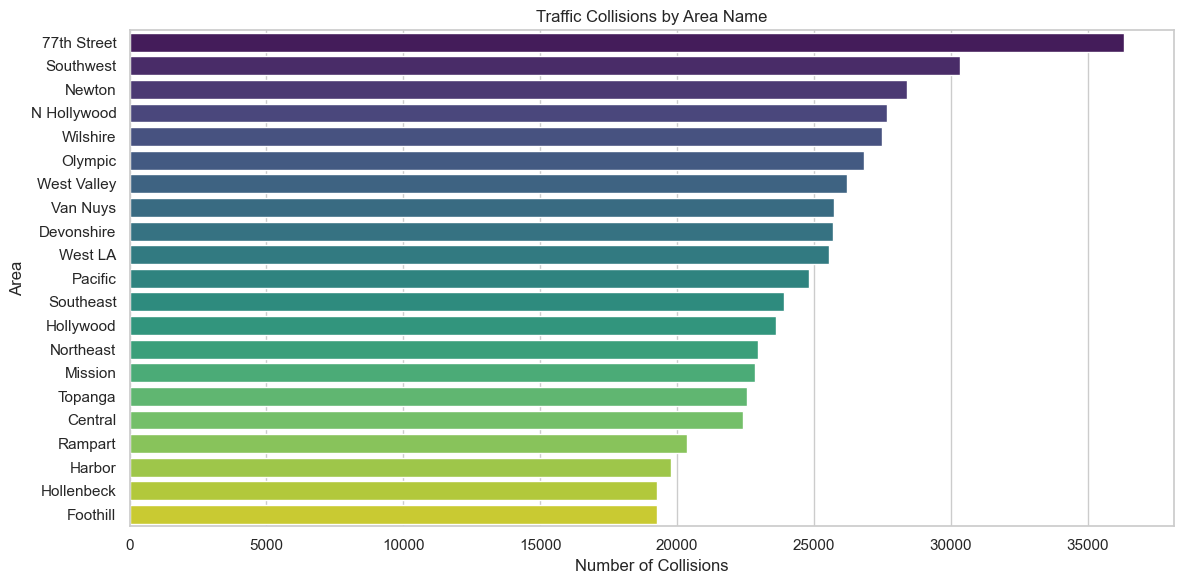

In [9]:
plt.figure(figsize=(12, 6))
area_counts = df_clean['Area Name'].value_counts()
sns.barplot(x=area_counts.values, y=area_counts.index, palette='viridis')
plt.title('Traffic Collisions by Area Name')
plt.xlabel('Number of Collisions')
plt.ylabel('Area')
plt.tight_layout()
plt.show()

EDA: Yearly & Monthly Trends

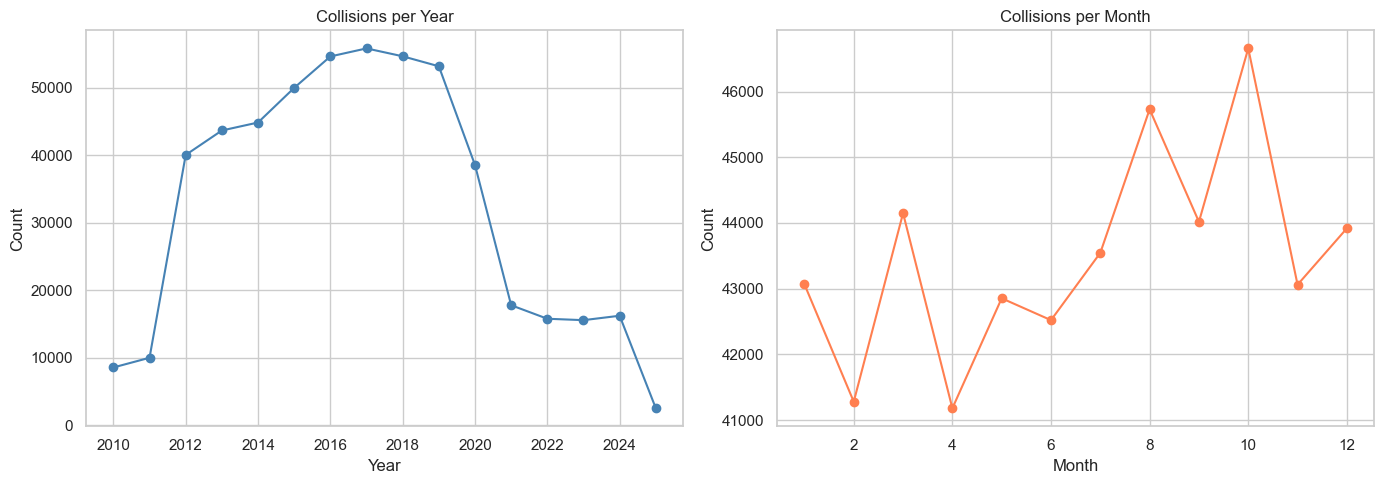

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Yearly
df_clean['year'] = df_clean['datetime'].dt.year
df_clean.groupby('year').size().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Collisions per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

# Monthly
df_clean['month'] = df_clean['datetime'].dt.month
df_clean.groupby('month').size().plot(ax=axes[1], marker='o', color='coral')
axes[1].set_title('Collisions per Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

EDA: Victim Demographics

/var/folders/f0/mndq6zwd6s50pdk9mrtksn1w0000gn/T/ipykernel_38196/2352364237.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_counts.index, y=sex_counts.values, palette='pastel', ax=axes[1])


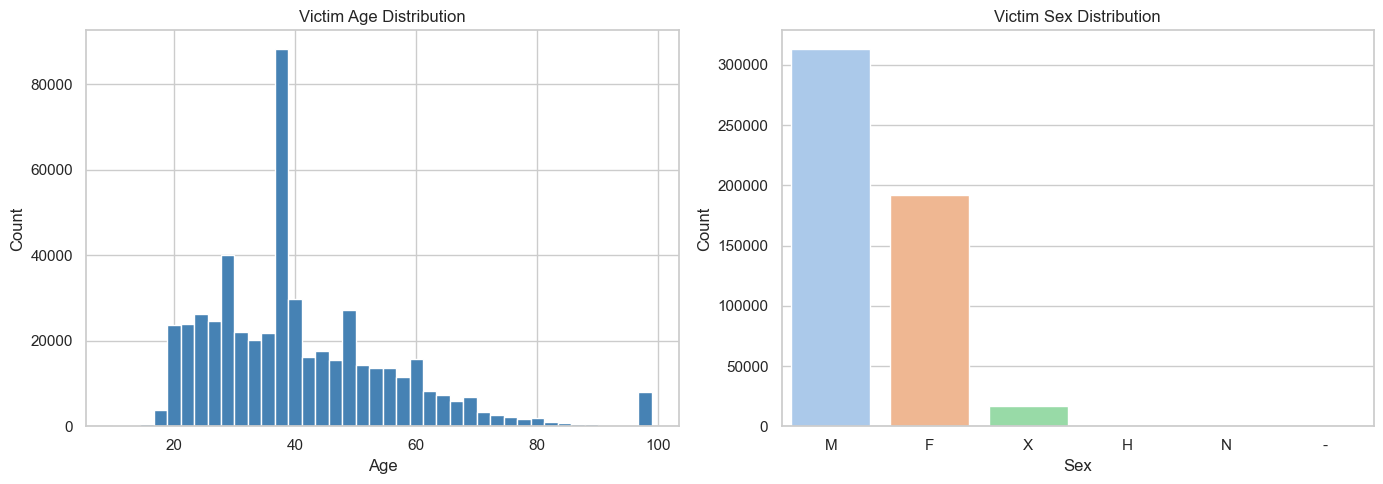

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Victim Age distribution
axes[0].hist(df_clean['Victim Age'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Victim Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Victim Sex
sex_counts = df_clean['Victim Sex'].value_counts()
sns.barplot(x=sex_counts.index, y=sex_counts.values, palette='pastel', ax=axes[1])
axes[1].set_title('Victim Sex Distribution')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

EDA: MO Code Severity Preview

In [12]:
# Check how many records contain severity MO codes
has_3024 = df_clean['MO Codes'].str.contains(r'\b3024\b', na=False).sum()
has_3027 = df_clean['MO Codes'].str.contains(r'\b3027\b', na=False).sum()
neither  = len(df_clean) - has_3024 - has_3027

print(f"Severe Injury (3024): {has_3024}")
print(f"Fatality     (3027): {has_3027}")
print(f"Minor/Other        : {neither}")

Severe Injury (3024): 16039
Fatality     (3027): 3224
Minor/Other        : 502710


Save Cleaned Data

In [14]:
df_clean.to_csv('collisions_clean.csv', index=False)
print("Saved collisions_clean.csv")

Saved collisions_clean.csv
